In [3]:
import numpy as np
from sklearn import linear_model
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('dark_background')

In [13]:


def draw_heatmap(df, title):
    piv = pd.pivot_table(df, values="avg_dim",index=["k_n"], columns=["deltas"], fill_value=0)
    ax = sns.heatmap(piv, square=True, cmap="viridis", annot=True, vmin=0.0, vmax=2.0)
    plt.setp( ax.xaxis.get_majorticklabels(), rotation=90 )
    plt.tight_layout()
    plt.title(title)
    plt.show()

In [2]:
ALL_DELTAS = [0.000625,0.00125,0.0025,0.005,0.01,0.02,0.04,0.08,0.16,0.32,0.64,1.28]
ALL_BACKBONES = ["maf", "rqnsf"]
ALL_KNS = [3, 5, 9, 17, 33, 65, 129, 257]

results = []

for backbone in ALL_BACKBONES:
    for k_n in  ALL_KNS:
        x = torch.load(f"/home/pt202342/projects/lidl/results/{backbone}/quantized_uniform-{k_n}/lls.torch")
        for i in range(0, (len(ALL_DELTAS) - 2)):
            deltas = np.array(ALL_DELTAS[i: i+3])
            lls = x [i:i + 3].transpose()
            total_dim = 2

            dims = list()
            for i in range(lls.shape[0]):
                good_inds = ~np.logical_or(np.isnan(lls[i]), np.isinf(lls[i]))
                if ~good_inds.all():
                    print(
                        f"[WARNING] some log likelihoods are incorrect, deltas: {deltas}")
                ds = np.log(deltas[good_inds])
                ll = lls[i][good_inds]
                if ll.size < 2:
                    dims.append(np.nan)
                else:
                    regr = linear_model.LinearRegression()
                    regr.fit(ds.reshape(-1, 1), ll)
                    regr.predict(ds.reshape(-1, 1))
                    dims.append(total_dim - regr.coef_[0])
            results.append({
                "k_n": k_n,
                "avg_dim": np.mean(dims),
                "backbone": backbone,
                "deltas": str(deltas),
                "dims": dims})

/home/pt202342/miniconda3/envs/id-diff/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


FileNotFoundError: [Errno 2] No such file or directory: '/home/pt202342/projects/lidl/results/maf/quantized_uniform-3/lls.torch'

In [62]:
df = pd.DataFrame(results)
df.to_json("results_quantised_uniform_val-is-train.json")
df.to_csv("results_quantised_uniform_val-is-train.csv", index=False)

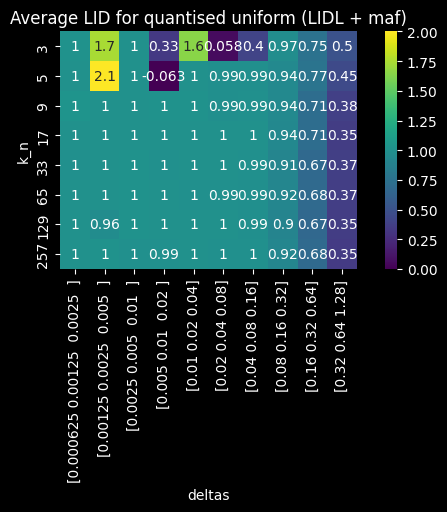

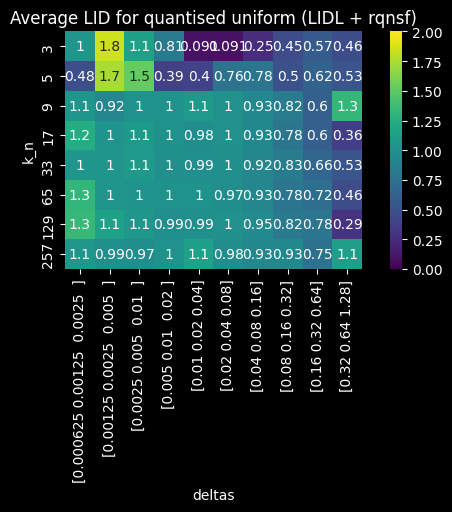

In [63]:


for backbone in ["maf", "rqnsf"]:
    draw_heatmap(df[df["backbone"] == backbone], f"Average LID for quantised uniform (LIDL + {backbone})")

In [55]:
df

,k_n,avg_dim,backbone,deltas,dims
0,3,1.012141,maf,[0.000625 0.00125 0.0025 ],"[1.0335324865867919, 1.01367089816925, 0.98921..."
1,3,1.740716,maf,[0.00125 0.0025 0.005 ],"[1.5890443600756032, 2.1216109962169023, 1.511..."
2,3,1.007673,maf,[0.0025 0.005 0.01 ],"[0.9760813381007689, 1.034730689715353, 1.0122..."
3,3,0.328723,maf,[0.005 0.01 0.02 ],"[0.3237638700942982, 0.5043122888659799, 0.158..."
4,3,1.644606,maf,[0.01 0.02 0.04],"[1.9493447459628208, 1.1252551338581984, 1.859..."
...,...,...,...,...,...
155,257,0.983181,rqnsf,[0.02 0.04 0.08],"[1.310631621587552, 1.2492590966792063, 1.1933..."
156,257,0.929845,rqnsf,[0.04 0.08 0.16],"[0.7025240138118758, 0.6644271049233501, 0.632..."
157,257,0.930424,rqnsf,[0.08 0.16 0.32],"[1.2707362901189543, 1.2515474978315875, 1.232..."
158,257,0.748445,rqnsf,[0.16 0.32 0.64],"[1.357993235878058, 1.344814205342441, 1.33170..."


In [61]:
from pathlib import Path


def quantized_uniform(root_data_path, n_k) -> tuple[np.ndarray, np.ndarray]:

    train_path = Path(root_data_path) / \
        "quantized_uniform" / f"{n_k}" / "train"
    test_path = Path(root_data_path) / "quantized_uniform" / f"{n_k}" / "test"

    def load_subset(path):
        train_data = np.load(path / "data.npy")
        train_lid = np.load(path / "lid.npy")
        train_coefficients = np.load(path / "coefficients.npy")
        return (train_data, train_lid, train_coefficients)

    train_data = load_subset(train_path)
    test_data = load_subset(test_path)

    return train_data, test_data


data = quantized_uniform("/home/pt202342/projects/lid-benchmark-datasets/data", 3)
train_dataset = data[0][0]
val_dataset = data[0][0]
test_dataset = data[1][0]

train_dataset.shape, val_dataset.shape, test_dataset.shape

((10000, 2), (10000, 2), (3, 2))

## new format

In [24]:
import numpy as np
from sklearn import linear_model
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('dark_background')


ALL_DELTAS = [0.00015625, 0.0003125, 0.000625,0.00125,0.0025,0.005,0.01,0.02,0.04,0.08,0.16,0.32,0.64,1.28]
ALL_BACKBONES = ["maf", "rqnsf"]
ALL_KNS = [3, 5, 9, 17, 33, 65, 129, 257]

results = []

for backbone in ALL_BACKBONES:
    for k_n in  ALL_KNS:
        for i in range(0, (len(ALL_DELTAS) - 2)):
            deltas = np.array(ALL_DELTAS[i: i+3])
            
            deltas_str = ';'.join([str(x) for x in np.array(ALL_DELTAS[i: i+3])])

            x = torch.load(f"/home/pt202342/projects/lidl/results/{backbone}/quantized_uniform-{k_n}/{deltas_str}/lls.torch")
            lls = x.transpose()
            total_dim = 2

            dims = list()
            for i in range(lls.shape[0]):
                good_inds = ~np.logical_or(np.isnan(lls[i]), np.isinf(lls[i]))
                if ~good_inds.all():
                    print(
                        f"[WARNING] some log likelihoods are incorrect, deltas: {deltas}")
                ds = np.log(deltas[good_inds])
                ll = lls[i][good_inds]
                if ll.size < 2:
                    dims.append(np.nan)
                else:
                    regr = linear_model.LinearRegression()
                    regr.fit(ds.reshape(-1, 1), ll)
                    regr.predict(ds.reshape(-1, 1))
                    dims.append(total_dim - regr.coef_[0])
            results.append({
                "k_n": k_n,
                "avg_dim": np.mean(dims),
                "backbone": backbone,
                "deltas": str(deltas),
                "dims": dims})

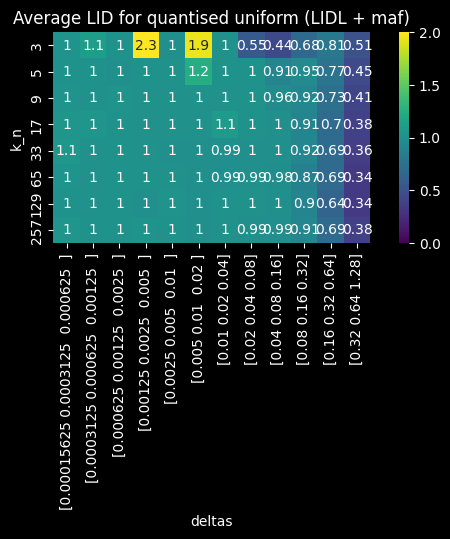

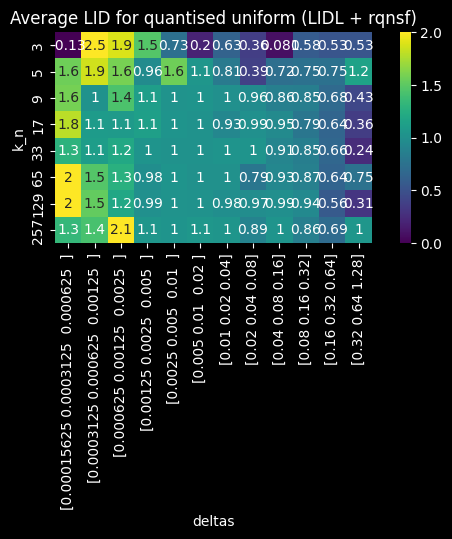

In [25]:
df = pd.DataFrame(results)
# df.to_json("results_quantised_uniform_val-is-train_trained-on-3-deltas.json")
# df.to_csv("results_quantised_uniform_val-is-train_trained-on-3-deltas.csv", index=False)

for backbone in ["maf", "rqnsf"]:
    draw_heatmap(df[df["backbone"] == backbone], f"Average LID for quantised uniform (LIDL + {backbone})")

In [10]:
[good_inds]

[array([ True,  True])]